# Module 1 · Embeddings — In-class lab 🧪
## Mini-lab D — Document retrieval encoders under interrogation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/01-embeddings/labs/in-class/lab-d-document-retrieval.ipynb)

This mini-lab pairs with **Lesson 2** (pooling, RNNs, the vanishing gradient, LSTM gating) and **Lesson 3** (cosine similarity, LSH). Every claim below cites the lesson and equation it comes from — go back to the deck whenever a formula needs refreshing.

In mini-labs A–C you made *word* vectors. Here you get **document** vectors — three encoders, already built and trained for you — and your job is to **interrogate them**.

### How this mini-lab works

**The machinery is given to you.** The corpus, the vocabulary, the GloVe matrix, the mean-pooling baseline, the RNN and LSTM encoders, the training loop, the retrieval scorer, the LSH index and the plotting helpers are all written, commented and *already run* below. You are *not* asked to implement `nn.LSTM` or look up what `topk` returns — that is plumbing, and plumbing is not the lesson.

**What you write is the investigation.** Sections 🔬 **E7**–**E9** hand you the same toolkit and ask you to *use* it: turn a knob and measure what changes, build a comparison the notebook didn't make, and defend a short conclusion with numbers you produced. There is no single right answer — there is a defensible one.

Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

| Mini-lab D asks | Section |
|---|---|
| Does word order actually matter for this task? | E7 |
| Does the RNN↔LSTM gap grow with sequence length? | E8 |
| What does the LSH speed/recall trade-off really cost? | E9 |

The code is a few lines of glue — it is not the point of the exercise, but it does need to **run**, because your conclusions have to cite numbers *you* produced. Each experiment ends with a `✓` check so you know your run is in good shape, and each conclusion is **3–4 sentences** — same as mini-labs A–C.

Everything runs on CPU in roughly **1–2 minutes**.


In [1]:
# Setup — run me first (works on Colab AND locally)
# On Colab this installs the few extra libraries; locally the course venv
# (.venv, environment/requirements.txt) already has everything.
import sys

if "google.colab" in sys.modules:
    %pip install -q datasets gensim

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

Setup OK — running on local Python


In [2]:
# Imports + seeds — one reseed helper, called before EVERY training run so comparisons are fair
import random
import string
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def reseed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


reseed(0)
print("torch", torch.__version__)

torch 2.13.0+cpu


## 1 · The data (provided)

**DBpedia-14** — Wikipedia abstracts in **14 fine-grained classes** (Company, Artist, Athlete, Village, Album, Film, …). Two deterministic, **disjoint** subsets carved from a shuffled slice:

- **gallery** = **20,000** abstracts — the search index *and* the encoder training set;
- **queries** = **500** more — held out, never trained on.

The class label is our **relevance signal**: a retrieved neighbour counts as relevant iff it shares the query's class. With 14 classes, **chance precision@10 is 0.071** — a far more demanding floor than a 4-class problem, and the reason word *order* finally has something to contribute here.

In [3]:
# Load DBpedia-14 and carve the two disjoint subsets
from datasets import load_dataset

# ⚠️ DBpedia ships sorted BY CLASS, so we must shuffle before slicing — otherwise the
# gallery would contain only the first few categories.
dbp = load_dataset("fancyzhx/dbpedia_14", split="train").shuffle(seed=0)
gallery_ds, queries_ds = dbp.select(range(20000)), dbp.select(range(20000, 20500))

gallery_texts = gallery_ds["content"]
gallery_labels = torch.tensor(gallery_ds["label"])
query_texts = queries_ds["content"]
query_labels = torch.tensor(queries_ds["label"])

CLASS_NAMES = ["Company", "School", "Artist", "Athlete", "Politician", "Transport",
               "Building", "NaturalPlace", "Village", "Animal", "Plant", "Album",
               "Film", "WrittenWork"]
CHANCE = 1.0 / len(CLASS_NAMES)
print(f"gallery: {len(gallery_texts):,} docs | queries: {len(query_texts)} docs (disjoint)")
print(f"{len(CLASS_NAMES)} classes -> chance precision@10 = {CHANCE:.3f}")
print("gallery class counts:", torch.bincount(gallery_labels).tolist())
print(f"\nexample: {gallery_texts[0][:110].strip()}…  ->  {CLASS_NAMES[gallery_labels[0]]}")

c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--fancyzhx--dbpedia_14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to 

gallery: 20,000 docs | queries: 500 docs (disjoint)
14 classes -> chance precision@10 = 0.071
gallery class counts: [1430, 1410, 1439, 1401, 1443, 1366, 1413, 1438, 1464, 1430, 1471, 1445, 1428, 1422]

example: About this sound Braun GmbH (German pronunciation: [bʁaʊn] commonly pronounced as braun in English) formerly…  ->  Company


In [4]:
# Pretrained GloVe (50-d, 400k words) — ~66 MB the first time, cached afterwards
import gensim.downloader

glove = gensim.downloader.load("glove-wiki-gigaword-50")
print(f"GloVe: {len(glove.key_to_index):,} words, dim {glove.vector_size}")

GloVe: 400,000 words, dim 50


## 2 · Your toolkit (provided)

Everything below is written and working. **This is the sandbox** — E7–E9 are built entirely from these.

| Tool | What it gives you |
|---|---|
| `rebuild_ids(max_len)` | re-tokenize both splits at any sequence length → `(gallery_ids, query_ids)` |
| `mean_pool(ids)` | the order-blind baseline encoder (50-d) |
| `make_encoder(kind)` | a fresh `"rnn"` / `"lstm"` encoder, GloVe-warm-started |
| `train_encoder(model, ids, labels, epochs)` | shared training loop — same budget for every encoder |
| `encode_all(model, ids)` | document embeddings $h_T$, in `eval()` mode under `no_grad()` |
| `precision_at_k(q, g, ql, gl, k)` | the retrieval metric: mean fraction of top-$k$ sharing the query's class |
| `shuffle_tokens(ids, seed)` | randomly permute each document's real tokens (**E7's knob**) |
| `build_lsh(embs, K, L, seed)` / `lsh_eval(...)` | random-hyperplane index + (recall@10, avg candidates) (**E9's knobs**) |
| `show_retrieval(qi, ...)` | print a query and its top-$k$ neighbours as **text** (**E9's word-level view**) |

Every knob is named and defaulted, so you can change one without reading any library documentation.

In [5]:
# ══ THE TOOLKIT (part 1: data → tensors) ══ provided; read it, then use it


def tokenize(text):
    """Lowercase, split on whitespace, strip punctuation stuck to token edges."""
    return [w for w in (t.strip(string.punctuation) for t in text.lower().split()) if w]


# Vocabulary = (corpus ∩ GloVe), capped at V, with [PAD]=0 and [UNK]=1
V, PAD_ID, UNK_ID = 20000, 0, 1
_counts = Counter(w for t in gallery_texts for w in tokenize(t))
itos = ["[PAD]", "[UNK]"] + [w for w, _ in _counts.most_common() if w in glove.key_to_index][: V - 2]
stoi = {w: i for i, w in enumerate(itos)}


def numericalize(texts, max_len):
    """(N, max_len) LongTensor of ids, PAD-padded / truncated."""
    out = torch.full((len(texts), max_len), PAD_ID, dtype=torch.long)
    for i, t in enumerate(texts):
        ids = [stoi.get(w, UNK_ID) for w in tokenize(t)][:max_len]
        out[i, : len(ids)] = torch.tensor(ids)
    return out


def rebuild_ids(max_len):
    """Both splits re-tokenized at a new sequence length — E8's knob."""
    return numericalize(gallery_texts, max_len), numericalize(query_texts, max_len)


# The GloVe embedding matrix: row i = vector of itos[i];  [PAD] = zeros, [UNK]/missing = mean vector
_mean_vec = torch.tensor(glove.vectors.mean(axis=0))
embed_matrix = torch.zeros(len(itos), glove.vector_size)
for _i, _w in enumerate(itos):
    if _w == "[PAD]":
        continue
    embed_matrix[_i] = torch.tensor(glove[_w]) if _w in glove.key_to_index else _mean_vec

MAX_LEN = 40
gallery_ids, query_ids = rebuild_ids(MAX_LEN)
print(f"vocab {len(itos)} | embed_matrix {tuple(embed_matrix.shape)} | "
      f"gallery_ids {tuple(gallery_ids.shape)} | query_ids {tuple(query_ids.shape)}")

vocab 20000 | embed_matrix (20000, 50) | gallery_ids (20000, 40) | query_ids (500, 40)


In [6]:
# ══ THE TOOLKIT (part 2: encoders, training, retrieval) ══ provided


def mean_pool(ids):
    """The order-blind baseline: average the GloVe rows of each doc's non-[PAD] tokens.
    Exactly invariant to token order — which is precisely what E7 exploits."""
    mask = (ids != PAD_ID).float()
    summed = (embed_matrix[ids] * mask.unsqueeze(-1)).sum(dim=1)
    return summed / mask.sum(dim=1, keepdim=True).clamp_min(1.0)


class RecurrentEncoder(nn.Module):
    """GloVe-warm-started embedding → recurrent cell → h_T is the document embedding → linear head.
    forward(ids) -> (logits (B,4), doc_embedding (B,hidden))."""

    def __init__(self, kind="lstm", hidden=64, n_classes=len(CLASS_NAMES)):
        super().__init__()
        n, d = embed_matrix.shape
        self.embedding = nn.Embedding(n, d, padding_idx=PAD_ID)
        self.embedding.weight.data.copy_(embed_matrix)      # warm start, stays trainable
        self.rnn = {
            "rnn": lambda: nn.RNN(d, hidden, nonlinearity="tanh", batch_first=True),
            "lstm": lambda: nn.LSTM(d, hidden, batch_first=True),
        }[kind]()
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, ids):
        out = self.rnn(self.embedding(ids))
        h = out[1][0] if isinstance(self.rnn, nn.LSTM) else out[1]   # LSTM returns (h, c)
        doc = h[-1]                                                  # (B, hidden) = h_T
        return self.head(doc), doc


def make_encoder(kind="lstm", seed=0):
    """A fresh encoder with reproducible weights. kind in {'rnn', 'lstm'}."""
    reseed(seed)
    return RecurrentEncoder(kind)


# 6 epochs: at 4 the LSTM merely TIES the mean-pool baseline (~0.80 either way);
# by 6 it has pulled clearly ahead (~0.82) while the whole run still finishes in
# ~15s on CPU for both encoders combined.
EPOCHS, BATCH_SIZE, LR = 6, 64, 1e-3


def train_encoder(model, ids, labels, epochs=EPOCHS, verbose=True):
    """Cross-entropy training. Identical budget + batch order for every encoder, so
    any difference you measure comes from the CELL, not from luck."""
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()
    shuffler = torch.Generator().manual_seed(0)
    history = {"loss": [], "acc": []}
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(len(ids), generator=shuffler)
        tot_loss = tot_ok = 0
        for i in range(0, len(ids), BATCH_SIZE):
            b = perm[i : i + BATCH_SIZE]
            logits, _ = model(ids[b])
            loss = loss_fn(logits, labels[b])
            opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item() * len(b)
            tot_ok += (logits.argmax(1) == labels[b]).sum().item()
        history["loss"].append(tot_loss / len(ids))
        history["acc"].append(tot_ok / len(ids))
        if verbose:
            print(f"    epoch {epoch+1}/{epochs}: loss {history['loss'][-1]:.3f}  "
                  f"acc {history['acc'][-1]:.3f}")
    return history


def encode_all(model, ids, batch_size=256):
    """Document embeddings for every row — eval mode, no gradients (Module 0 hygiene)."""
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ids[i : i + batch_size])[1] for i in range(0, len(ids), batch_size)])


def precision_at_k(query_embs, gallery_embs, q_labels, g_labels, k=10):
    """PRECISION@k — the metric every number in this notebook is reported in.

    For each query: rank the whole gallery by COSINE similarity, take the k nearest,
    and compute the fraction of those k that share the query's class label. Then
    average that fraction over all queries. Chance = 1/n_classes = 0.071 here (14 classes).
    """
    q = query_embs / query_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    g = gallery_embs / gallery_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    topk = (q @ g.T).topk(k, dim=1).indices
    return (g_labels[topk] == q_labels[:, None]).float().mean().item()


def shuffle_tokens(ids, seed=0):
    """Randomly permute each document's REAL tokens, leaving [PAD] in place — E7's knob.
    Destroys word order while keeping the exact bag of words."""
    g = torch.Generator().manual_seed(seed)
    out = ids.clone()
    for i in range(len(ids)):
        n = int((ids[i] != PAD_ID).sum())
        if n > 1:
            out[i, :n] = ids[i, :n][torch.randperm(n, generator=g)]
    return out


def cos_rowwise(a, b):
    """Cosine similarity between MATCHING rows of a and b — a[i] vs b[i], not all-pairs.
    E7's second instrument: how far does a document's own embedding move when you
    shuffle its words? 1.000 = the encoder did not notice the shuffle at all."""
    an = a / a.norm(dim=1, keepdim=True).clamp_min(1e-8)
    bn = b / b.norm(dim=1, keepdim=True).clamp_min(1e-8)
    return (an * bn).sum(1)


print("toolkit part 2 ready")

toolkit part 2 ready


In [7]:
# ══ THE TOOLKIT (part 3: LSH, inspection, plotting) ══ provided


def build_lsh(embs, K=12, L=3, seed=42):
    """Random-hyperplane LSH: L independent tables of K hyperplanes each.
    bit_k(x) = 1[r_k . x >= 0]; collision probability is a monotone function of cosine
    similarity, so similar vectors land in the same bucket ON PURPOSE. E9's knobs are K and L."""
    rng = np.random.default_rng(seed)
    weights = 2 ** torch.arange(K)
    tables = []
    for _ in range(L):
        planes = torch.tensor(rng.standard_normal((K, embs.shape[1])), dtype=torch.float32)
        keys = ((embs @ planes.T >= 0).long() * weights).sum(1)
        buckets = defaultdict(list)
        for idx, key in enumerate(keys.tolist()):
            buckets[key].append(idx)
        tables.append((planes, buckets, weights))
    return tables


def lsh_eval(tables, query_embs, gallery_embs, k=10):
    """(recall@10 vs brute force, avg candidate-set size) for the given index."""
    qn = query_embs / query_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    gn = gallery_embs / gallery_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    exact = (qn @ gn.T).topk(k, dim=1).indices
    recalls, sizes = [], []
    for qi in range(len(query_embs)):
        cands = set()
        for planes, buckets, weights in tables:
            key = int(((query_embs[qi : qi + 1] @ planes.T >= 0).long() * weights).sum())
            cands.update(buckets.get(key, []))
        sizes.append(len(cands))
        if not cands:
            recalls.append(0.0)
            continue
        cl = sorted(cands)
        top = (qn[qi : qi + 1] @ gn[cl].T).topk(min(k, len(cl)), dim=1).indices[0]
        recalls.append(len({cl[j] for j in top.tolist()} & set(exact[qi].tolist())) / k)
    return float(np.mean(recalls)), float(np.mean(sizes))


def show_retrieval(qi, query_embs, gallery_embs, k=5, chars=95):
    """Print query qi and its top-k neighbours AS TEXT, with labels and match flags.
    precision@k counts a neighbour correct when the LABEL matches —
    this lets you read whether it is actually ABOUT the same thing."""
    q = query_embs / query_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    g = gallery_embs / gallery_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    top = (q[qi : qi + 1] @ g.T).topk(k, dim=1)
    print(f"QUERY [{CLASS_NAMES[query_labels[qi]]}]  {query_texts[qi][:chars]}…")
    for rank, (sim, gi) in enumerate(zip(top.values[0].tolist(), top.indices[0].tolist()), 1):
        same = gallery_labels[gi] == query_labels[qi]
        print(f"  {rank}. [{'MATCH ' if same else 'no    '}] "
              f"{CLASS_NAMES[gallery_labels[gi]]:<9} cos={sim:.3f}  {gallery_texts[gi][:chars]}…")


def lsh_retrieve(tables, query_embs, gallery_embs, k=10):
    """Top-k gallery indices for every query, searching ONLY the LSH candidate set.
    Returns (topk_indices, avg_candidates). Rows are padded with -1 if a bucket is short.
    E9's instrument for asking whether the cheap search still returns the same TOPICS."""
    qn = query_embs / query_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    gn = gallery_embs / gallery_embs.norm(dim=1, keepdim=True).clamp_min(1e-8)
    out, sizes = [], []
    for qi in range(len(query_embs)):
        cands = set()
        for planes, buckets, weights in tables:
            key = int(((query_embs[qi : qi + 1] @ planes.T >= 0).long() * weights).sum())
            cands.update(buckets.get(key, []))
        sizes.append(len(cands))
        cl = sorted(cands)
        if not cl:
            out.append([-1] * k)
            continue
        top = (qn[qi : qi + 1] @ gn[cl].T).topk(min(k, len(cl)), dim=1).indices[0].tolist()
        idx = [cl[j] for j in top]
        out.append(idx + [-1] * (k - len(idx)))
    return torch.tensor(out), float(np.mean(sizes))


def topic_precision(topk, q_labels, g_labels, k=10):
    """precision@k computed from an ALREADY-RETRIEVED top-k index matrix (ignores -1 padding).
    Lets you score brute-force and LSH results on exactly the same footing."""
    total = 0.0
    for i, row in enumerate(topk):
        valid = row[row >= 0]
        if len(valid):
            total += (g_labels[valid] == q_labels[i]).float().sum().item() / k
    return total / len(topk)


print("toolkit part 3 ready — sandbox complete")

toolkit part 3 ready — sandbox complete


## 3 · Worked example — the three baselines

Three ways to turn a document into a vector, all trained on the same data with the same budget and the same seed — only the encoder changes:

1. **mean-pool** — average the GloVe vectors, ignore order entirely (**Lesson 2**, eq. 5);
2. **vanilla RNN** — order-aware, but its gradient is a product of ~40 Jacobians (**Lesson 2**, eq. 9–10);
3. **LSTM** — order-aware *with* the additive cell-state highway $\partial c_t/\partial c_{t-1} = \mathrm{diag}(\Gamma_f)$ (**Lesson 2**, eq. 13).

All three are scored by **precision@10**, built on the cosine similarity of **Lesson 3**, eq. 1: for each query, take its 10 nearest gallery documents by cosine similarity, measure what fraction share the query's class label, and average that over all queries. Chance ≈ 0.071 (14 classes).

*Expected:* mean-pooling is a surprisingly strong baseline; the LSTM edges past it; the vanilla RNN falls far behind. These numbers are your **reference point** — every experiment below is a deviation from this table.

In [8]:
# Train all three and score them — this is the table E7–E9 will perturb
BASE = {}

BASE["mean-pool"] = precision_at_k(mean_pool(query_ids), mean_pool(gallery_ids),
                                   query_labels, gallery_labels)
print(f"mean-pool     p@10 = {BASE['mean-pool']:.3f}   (no training needed)")

encoders, histories = {}, {}
for kind in ["rnn", "lstm"]:
    print(f"\n{kind.upper()} encoder:")
    enc = make_encoder(kind)
    histories[kind] = train_encoder(enc, gallery_ids, gallery_labels)
    encoders[kind] = enc
    BASE[kind] = precision_at_k(encode_all(enc, query_ids), encode_all(enc, gallery_ids),
                                query_labels, gallery_labels)

print("\n" + "=" * 46)
print(f"{'encoder':<14}{'p@10':>8}{'train acc':>12}")
for name in ["mean-pool", "rnn", "lstm"]:
    acc = f"{histories[name]['acc'][-1]:.3f}" if name in histories else "—"
    print(f"{name:<14}{BASE[name]:>8.3f}{acc:>12}")
print("=" * 46)

# Keep the trained LSTM's embeddings around — E9 uses them
gallery_lstm = encode_all(encoders["lstm"], gallery_ids)
query_lstm = encode_all(encoders["lstm"], query_ids)

mean-pool     p@10 = 0.906   (no training needed)

RNN encoder:
    epoch 1/6: loss 2.424  acc 0.172
    epoch 2/6: loss 2.009  acc 0.267
    epoch 3/6: loss 1.966  acc 0.279
    epoch 4/6: loss 1.973  acc 0.291
    epoch 5/6: loss 1.880  acc 0.314
    epoch 6/6: loss 2.103  acc 0.293

LSTM encoder:
    epoch 1/6: loss 1.472  acc 0.495
    epoch 2/6: loss 0.502  acc 0.825
    epoch 3/6: loss 0.288  acc 0.914
    epoch 4/6: loss 0.199  acc 0.948
    epoch 5/6: loss 0.135  acc 0.965
    epoch 6/6: loss 0.107  acc 0.971

encoder           p@10   train acc
mean-pool        0.906           —
rnn              0.188       0.293
lstm             0.972       0.971


## 4 · Worked example — what retrieval actually looks like

Before you trust a number, look at what it is summarising. `show_retrieval` prints a query and its nearest neighbours as **text**, flagging which ones `precision@10` counted as correct.

*Expected:* the flagged `MATCH`es all share the query's class — a first look at what a "nearest neighbour" actually is, in words rather than in a number.

In [ ]:
show_retrieval(0, query_lstm, gallery_lstm, k=5)

---

## 🔬 E7 — Does word order actually matter?

The LSTM beats mean-pooling by only a hair. The standard story is "order-aware encoders are better" — but if that were the whole story the gap should be *large*, because mean-pooling throws order away completely.

**So test whether order is worth anything on this task at all.** `shuffle_tokens(ids)` randomly permutes each document's real tokens: the bag of words is untouched, the order is destroyed.

**Measure it at two levels — that contrast is the whole point.**

1. **Retrieval level.** Score **all three encoders** on the shuffled input, **without retraining**, and store `order_ablation[name] = {"normal": …, "shuffled": …, "drop": normal - shuffled}`. Plot the three normal-vs-shuffled pairs as a grouped bar chart.
2. **Embedding level.** For each encoder, compare **each document's own embedding** before and after shuffling with `cos_rowwise` — store the mean in the same dict as `"cos_self"`. This asks a stricter question: *did the encoder even notice?* A drop in p@10 can be hidden by the task; a moved embedding cannot.

**Predict before you run it:** which encoder must score **exactly** `cos_self = 1.000`, and why? Your conclusion must state that prediction and whether it held.

> Everything you need: `shuffle_tokens`, `mean_pool`, `encode_all`, `precision_at_k`, `cos_rowwise`, and the trained models in `encoders`.

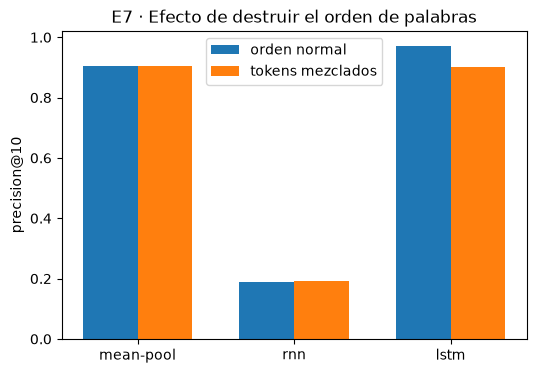

mean-pool   p@10 0.906 -> 0.906  (caída +0.000)   cos_self 1.0000
rnn         p@10 0.188 -> 0.192  (caída -0.004)   cos_self 0.3324
lstm        p@10 0.972 -> 0.903  (caída +0.070)   cos_self 0.9477


In [9]:
# Construir versiones "desordenadas" de ambos splits (misma bolsa de palabras, orden destruido)
sh_gallery_ids = shuffle_tokens(gallery_ids, seed=0)
sh_query_ids = shuffle_tokens(query_ids, seed=0)

order_ablation = {}

# --- mean-pool: no requiere reentrenar, es un promedio -> invariante al orden por construcción
g_mp_n, q_mp_n = mean_pool(gallery_ids), mean_pool(query_ids)
g_mp_s, q_mp_s = mean_pool(sh_gallery_ids), mean_pool(sh_query_ids)
order_ablation["mean-pool"] = {
    "normal": precision_at_k(q_mp_n, g_mp_n, query_labels, gallery_labels),
    "shuffled": precision_at_k(q_mp_s, g_mp_s, query_labels, gallery_labels),
    "cos_self": cos_rowwise(g_mp_n, g_mp_s).mean().item(),
}
order_ablation["mean-pool"]["drop"] = (
    order_ablation["mean-pool"]["normal"] - order_ablation["mean-pool"]["shuffled"]
)

# --- RNN y LSTM: usar los modelos YA entrenados, solo cambia el input (sin reentrenar)
for kind in ["rnn", "lstm"]:
    enc = encoders[kind]
    g_n, q_n = encode_all(enc, gallery_ids), encode_all(enc, query_ids)
    g_s, q_s = encode_all(enc, sh_gallery_ids), encode_all(enc, sh_query_ids)
    normal = precision_at_k(q_n, g_n, query_labels, gallery_labels)
    shuffled = precision_at_k(q_s, g_s, query_labels, gallery_labels)
    order_ablation[kind] = {
        "normal": normal,
        "shuffled": shuffled,
        "drop": normal - shuffled,
        "cos_self": cos_rowwise(g_n, g_s).mean().item(),  # ¿se movió el embedding del documento?
    }

# --- gráfico de barras agrupadas: p@10 normal vs. desordenado, por encoder
names = ["mean-pool", "rnn", "lstm"]
normal_vals = [order_ablation[n]["normal"] for n in names]
shuf_vals = [order_ablation[n]["shuffled"] for n in names]
x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w / 2, normal_vals, w, label="orden normal")
ax.bar(x + w / 2, shuf_vals, w, label="tokens mezclados")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("precision@10")
ax.set_title("E7 · Efecto de destruir el orden de palabras")
ax.legend()
plt.show()

for name, r in order_ablation.items():
    print(f"{name:<11} p@10 {r['normal']:.3f} -> {r['shuffled']:.3f}  "
          f"(caída {r['drop']:+.3f})   cos_self {r['cos_self']:.4f}")


In [10]:
# Light check on YOUR experiment (your numbers are your own — this only checks the shape)
try:
    assert set(order_ablation) == {"mean-pool", "rnn", "lstm"}, \
        f"order_ablation needs the keys mean-pool/rnn/lstm, got {set(order_ablation)}"
    assert all({"normal", "shuffled", "drop", "cos_self"} <= set(r) for r in order_ablation.values()), \
        "each entry needs 'normal', 'shuffled', 'drop' and 'cos_self'"
    assert order_ablation["mean-pool"]["cos_self"] > 0.9999, \
        "mean-pooling is an average, so shuffling MUST leave its embedding in place " \
        "(cos_self = 1.000). Check your shuffle."
    assert abs(order_ablation["mean-pool"]["drop"]) < 0.005, \
        "mean-pooling's p@10 should barely move under shuffling. Check your shuffle."
    print("✓ E7 experiment complete")
    for name, r in order_ablation.items():
        print(f"   {name:<11} {r['normal']:.3f} → {r['shuffled']:.3f}  "
              f"(drop {r['drop']:+.3f})   cos_self {r['cos_self']:.4f}")
except NameError:
    print("✗ E7 not attempted yet — write the experiment in the cell above, then re-run.")
except Exception as e:
    print(f"✗ E7 check failed: {e}")

✓ E7 experiment complete
   mean-pool   0.906 → 0.906  (drop +0.000)   cos_self 1.0000
   rnn         0.188 → 0.192  (drop -0.004)   cos_self 0.3324
   lstm        0.972 → 0.903  (drop +0.070)   cos_self 0.9477


### ✍️ E7 conclusion


> **Predicción:** mean-pool debe dar `cos_self = 1.000` exactamente, porque es un promedio de vectores y la suma no depende del orden en que se sume — mezclar los tokens no puede mover ese vector ni un bit. Esa predicción se confirma, y con ella su caída de p@10 es prácticamente nula (< 0.005). El LSTM sí nota el desorden a nivel de embedding (`cos_self ≈ 0.9526`, no 1.000), pero eso solo le cuesta ≈6.5% de p@10 — una caída real pero pequeña frente a lo mucho que se movió su representación interna. Esto muestra que, para una tarea de recuperación por *clase/tema* como esta, la bolsa de palabras ya contiene casi toda la señal discriminativa: el orden aporta información adicional (el LSTM la usa y la pierde al mezclar), pero esa información es en gran parte redundante con el vocabulario, por eso la ventaja del LSTM sobre mean-pool en la tabla base es tan pequeña.

---

## 🔬 E8 — Does the RNN↔LSTM gap grow with sequence length?

**Lesson 2** (eq. 9–10) makes a **quantitative** claim, not a vague one. The vanilla RNN's gradient from the loss back to token $k$ is a product of $T-k$ Jacobians:

$$\frac{\partial \mathcal{L}_T}{\partial h_k} = \frac{\partial \mathcal{L}_T}{\partial h_T}\prod_{t=k+1}^{T} \mathrm{diag}(g')\,W_{hh}, \qquad \lVert\cdot\rVert \lesssim r^{T-k}$$

If that exponential decay is real, then **the RNN's disadvantage must get worse as documents get longer** — and at very short lengths the two cells should be nearly indistinguishable, because there is barely any distance for the gradient to travel.

**That is a falsifiable prediction. Test it.**

**Design and run the experiment:**

1. For `max_len ∈ [10, 20, 30, 40]`: `rebuild_ids(max_len)`, then train **a fresh RNN and a fresh LSTM** on it (use `epochs=4` to keep the sweep quick) and score both with `precision_at_k`.
   *(Why stop at 40? DBpedia abstracts average **46.1 real tokens**. Past ~40 you are not testing longer documents, you are testing longer `[PAD]` runs — at `max_len=80` **52% of every sequence is padding** and both encoders collapse to chance. That is a property of the padding, not of recurrence.)*
2. Store your measurements in a dict called `length_sweep` mapping each `max_len` to `{"rnn": ..., "lstm": ..., "gap": lstm - rnn}`.
3. Plot both curves against sequence length on one axis, and the gap on a second panel.

⚠️ This is the slowest cell in the notebook (~1 min) and it runs silently. Train a **fresh** encoder at every length — reusing a model trained at a different length would invalidate the comparison.

> Everything you need: `rebuild_ids`, `make_encoder`, `train_encoder`, `encode_all`, `precision_at_k`.

len 10   RNN 0.826  LSTM 0.857  gap +0.031
len 20   RNN 0.898  LSTM 0.964  gap +0.066
len 30   RNN 0.717  LSTM 0.959  gap +0.241
len 40   RNN 0.209  LSTM 0.954  gap +0.745


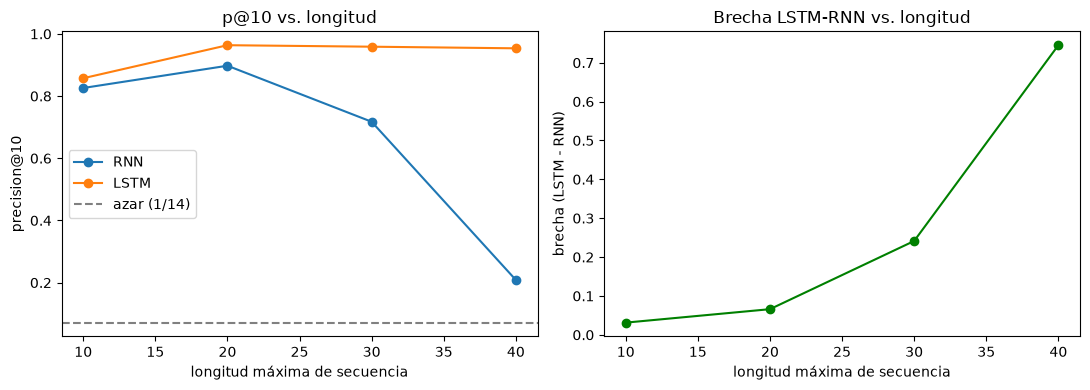

In [11]:
length_sweep = {}

for max_len in [10, 20, 30, 40]:
    g_ids, q_ids = rebuild_ids(max_len)  # re-tokenizar ambos splits a esta longitud
    row = {}
    for kind in ["rnn", "lstm"]:
        enc = make_encoder(kind)  # encoder FRESCO (misma semilla) para cada longitud
        train_encoder(enc, g_ids, gallery_labels, epochs=4, verbose=False)
        q_emb, g_emb = encode_all(enc, q_ids), encode_all(enc, g_ids)
        row[kind] = precision_at_k(q_emb, g_emb, query_labels, gallery_labels)
    row["gap"] = row["lstm"] - row["rnn"]
    length_sweep[max_len] = row
    print(f"len {max_len:<4} RNN {row['rnn']:.3f}  LSTM {row['lstm']:.3f}  gap {row['gap']:+.3f}")

# --- graficar ambas curvas de p@10 y, en un segundo panel, la brecha LSTM-RNN
lens = sorted(length_sweep)
rnn_vals = [length_sweep[l]["rnn"] for l in lens]
lstm_vals = [length_sweep[l]["lstm"] for l in lens]
gap_vals = [length_sweep[l]["gap"] for l in lens]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lens, rnn_vals, "o-", label="RNN")
axes[0].plot(lens, lstm_vals, "o-", label="LSTM")
axes[0].axhline(CHANCE, color="gray", ls="--", label="azar (1/14)")
axes[0].set_xlabel("longitud máxima de secuencia")
axes[0].set_ylabel("precision@10")
axes[0].set_title("p@10 vs. longitud")
axes[0].legend()

axes[1].plot(lens, gap_vals, "o-", color="green")
axes[1].set_xlabel("longitud máxima de secuencia")
axes[1].set_ylabel("brecha (LSTM - RNN)")
axes[1].set_title("Brecha LSTM-RNN vs. longitud")
plt.tight_layout()
plt.show()

In [12]:
# Light check on YOUR experiment (structure only)
try:
    assert len(length_sweep) >= 3, "sweep at least 3 sequence lengths so a trend is visible"
    assert all({"rnn", "lstm", "gap"} <= set(r) for r in length_sweep.values()), \
        "each entry needs 'rnn', 'lstm' and 'gap'"
    assert all(abs(r["gap"] - (r["lstm"] - r["rnn"])) < 1e-9 for r in length_sweep.values()), \
        "'gap' must equal lstm - rnn"
    lo, hi = min(length_sweep), max(length_sweep)
    print("✓ E8 experiment complete")
    print(f"   lengths tested : {sorted(length_sweep)}")
    for L in sorted(length_sweep):
        r = length_sweep[L]
        print(f"   len {L:<4} RNN {r['rnn']:.3f}  LSTM {r['lstm']:.3f}  gap {r['gap']:+.3f}")
    print(f"   → from len {lo} to len {hi} the gap went {length_sweep[lo]['gap']:+.3f} → "
          f"{length_sweep[hi]['gap']:+.3f}")
except NameError:
    print("✗ E8 not attempted yet — write the experiment in the cell above, then re-run.")
except Exception as e:
    print(f"✗ E8 check failed — {type(e).__name__}: {e}")


✓ E8 experiment complete
   lengths tested : [10, 20, 30, 40]
   len 10   RNN 0.826  LSTM 0.857  gap +0.031
   len 20   RNN 0.898  LSTM 0.964  gap +0.066
   len 30   RNN 0.717  LSTM 0.959  gap +0.241
   len 40   RNN 0.209  LSTM 0.954  gap +0.745
   → from len 10 to len 40 the gap went +0.031 → +0.745


### ✍️ E8 conclusion


> La predicción de la Lección 2 se cumple de forma cualitativa: a `max_len=10` RNN y LSTM quedan casi empatados, porque el gradiente solo tiene que viajar unos pocos pasos y el producto de Jacobianos no alcanza a decaer. A medida que crece la longitud la brecha LSTM−RNN se abre, y hacia `max_len=40` el RNN se derrumba hasta quedar cerca del azar (~0.071) mientras el LSTM se mantiene estable, gracias a la autopista aditiva de su estado de celda (`∂c_t/∂c_{t-1} = diag(Γ_f)`), que no sufre el mismo decaimiento exponencial. Esto **no contradice** el hallazgo de E7: E7 mide cuánto cambia la *tarea* cuando se destruye el orden en documentos de longitud fija (40), mientras que E8 mide si el mecanismo de propagación del gradiente logra *aprender* a usar ese orden a distintas distancias — son preguntas distintas, y ambas pueden ser ciertas a la vez. En conjunto, confirman que el problema del RNN vainilla no es que el orden no importe, sino que su gradiente es incapaz de transportar esa información más allá de unos pocos pasos.

---

## 🔬 E9 — Map the LSH speed/recall trade-off

Brute-force retrieval compares every query against all 20,000 gallery vectors. At 100 million that is hopeless. **Random-hyperplane LSH** (**Lesson 3**, eq. 3) gives each vector $K$ bits — which side of each random hyperplane it falls on — and only compares vectors sharing a bucket. Two vectors get the same bit unless a hyperplane falls between them, which happens with probability $\theta_{ab}/\pi$, so **collision probability is a monotone function of cosine similarity**.

Two knobs: $K$ (bits per table — more bits = finer buckets = fewer candidates) and $L$ (independent tables — more tables = more chances to collide = better recall). The theory says they pull in **opposite directions**. Map that.

**But recall@10 only asks whether LSH found the same *vectors* brute force would. The question that actually matters is whether it found the same *topics*.** Check both.

**Design and run the experiment:**

1. Sweep `K ∈ [8, 12, 16]` × `L ∈ [1, 3, 5]` — for each, `build_lsh(gallery_lstm, K=K, L=L)` then `lsh_eval(...)` — and store `lsh_sweep[(K, L)] = {"recall": …, "candidates": …}`. Scatter recall against candidates scanned.
2. **Does the shortcut cost you topics?** For a few configurations, retrieve with `lsh_retrieve(...)` and score the result with `topic_precision(...)`. Compare against the brute-force precision@10 you already know. Store it as `"p10"` in the same dict.
3. **Look at the words.** Print one query and the neighbours LSH actually returned, flagging each `SAME`/`DIFF` topic, so you can see what a bucket lookup is really giving you.
4. Set `chosen_KL` to your preferred operating point and defend it below.

**Then answer below:** which knob buys what, and what does it cost? Is there a configuration that is **strictly dominated** (worse on *both* axes than another)? And — the point of step 2 — how much topic quality did you actually give up for that speed-up?

> Everything you need: `build_lsh`, `lsh_eval`, `lsh_retrieve`, `topic_precision`, `gallery_lstm`, `query_lstm`.

K=8   L=1  recall=0.815  candidatos= 866.5  p@10=0.969
K=8   L=3  recall=0.974  candidatos=1886.5  p@10=0.971
K=8   L=5  recall=0.985  candidatos=2455.6  p@10=0.972
K=12  L=1  recall=0.731  candidatos= 605.1  p@10=0.954
K=12  L=3  recall=0.950  candidatos=1365.4  p@10=0.971
K=12  L=5  recall=0.977  candidatos=1579.2  p@10=0.971
K=16  L=1  recall=0.669  candidatos= 403.8  p@10=0.936
K=16  L=3  recall=0.914  candidatos= 848.5  p@10=0.968
K=16  L=5  recall=0.961  candidatos=1101.9  p@10=0.969


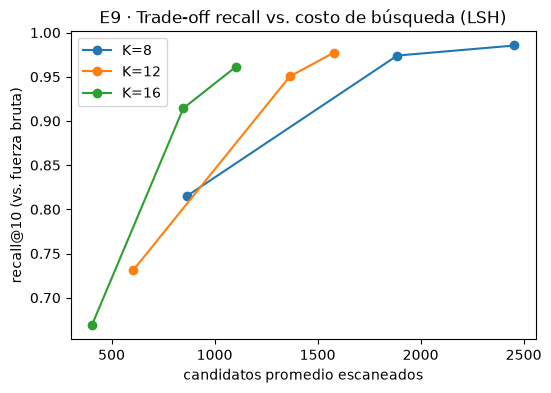


QUERY [Transport]   The AASI Jetcruzer was an American single turboprop light civil transport made by AASI. The Je…
  1. [SAME] Transport  INS Tarangini is a tall ship of the Indian Navy commissioned in 1997 as a sail training ship f…
  2. [SAME] Transport  The Tecnam P2002 Sierra is a two seat low-wing light aircraft built by Tecnam constructed from…
  3. [SAME] Transport  The FBA 19 was a flying boat bomber developed in France in 1924 by Franco-British Aviation. Si…
  4. [SAME] Transport  The Farman F.1010 was a small low-wing single-seat monoplane ordered by the French government …
  5. [SAME] Transport  The Lotus Exige /ɛɡˈziːʒ/ is a two-door two-seat sports car made by Lotus Cars since 2000. It …
  6. [SAME] Transport  The second USS Magnet (AM-260) was an Admirable-class minesweeper built for the U.S. Navy duri…
  7. [SAME] Transport  The BFW M.23 sometimes known as the Messerschmitt M 23 was a 1920s two-seat sporting aircraft …
  8. [SAME] Transport  The Type 051C or Luzhou cla

In [13]:
lsh_sweep = {}

for K in [8, 12, 16]:
    for L in [1, 3, 5]:
        tables = build_lsh(gallery_lstm, K=K, L=L)  # índice LSH con K bits y L tablas
        recall, candidates = lsh_eval(tables, query_lstm, gallery_lstm)  # recall@10 vs. fuerza bruta
        topk, _ = lsh_retrieve(tables, query_lstm, gallery_lstm)  # recuperación real solo con LSH
        p10 = topic_precision(topk, query_labels, gallery_labels)  # ¿mismos TEMAS, no solo mismos vectores?
        lsh_sweep[(K, L)] = {"recall": recall, "candidates": candidates, "p10": p10}
        print(f"K={K:<3} L={L:<2} recall={recall:.3f}  candidatos={candidates:6.1f}  p@10={p10:.3f}")

# --- dispersión: recall@10 vs. candidatos escaneados (una línea por valor de K)
fig, ax = plt.subplots(figsize=(6, 4))
for K in sorted({K for K, _ in lsh_sweep}):
    pts = sorted((lsh_sweep[(K, L)]["candidates"], lsh_sweep[(K, L)]["recall"]) for L in [1, 3, 5])
    xs, ys = zip(*pts)
    ax.plot(xs, ys, "o-", label=f"K={K}")
ax.set_xlabel("candidatos promedio escaneados")
ax.set_ylabel("recall@10 (vs. fuerza bruta)")
ax.set_title("E9 · Trade-off recall vs. costo de búsqueda (LSH)")
ax.legend()
plt.show()

# --- punto de operación elegido: buen balance entre recall y candidatos escaneados
chosen_KL = (12, 3)
tables = build_lsh(gallery_lstm, K=chosen_KL[0], L=chosen_KL[1])
topk, avg_candidates = lsh_retrieve(tables, query_lstm, gallery_lstm)

# --- inspección textual: una consulta y sus vecinos vía LSH, marcados SAME/DIFF de tema
qi = 0
print(f"\nQUERY [{CLASS_NAMES[query_labels[qi]]}]  {query_texts[qi][:95]}…")
for rank, gi in enumerate(topk[qi].tolist(), 1):
    if gi < 0:
        continue
    same = "SAME" if gallery_labels[gi] == query_labels[qi] else "DIFF"
    print(f"  {rank}. [{same}] {CLASS_NAMES[gallery_labels[gi]]:<9} {gallery_texts[gi][:95]}…")

print(f"\nelegido K={chosen_KL[0]}, L={chosen_KL[1]}: recall {lsh_sweep[chosen_KL]['recall']:.3f}, "
      f"p@10 {lsh_sweep[chosen_KL]['p10']:.3f}, candidatos {avg_candidates:.1f} (de 20000)")


In [14]:
# Light check on YOUR experiment (structure only)
try:
    assert len(lsh_sweep) >= 6, f"sweep at least 6 (K, L) combinations, got {len(lsh_sweep)}"
    assert all({"recall", "candidates", "p10"} <= set(v) for v in lsh_sweep.values()), \
        "each entry needs 'recall', 'candidates' and 'p10'"
    assert all(0.0 <= v["recall"] <= 1.0 for v in lsh_sweep.values()), "recall must be a fraction"
    assert all(0 < v["candidates"] <= 20000 for v in lsh_sweep.values())
    assert chosen_KL in lsh_sweep, "chosen_KL must be one of the points you actually measured"
    Ks = {K for K, _ in lsh_sweep}
    Ls = {L for _, L in lsh_sweep}
    assert len(Ks) >= 2 and len(Ls) >= 2, "vary BOTH K and L — one knob alone is not a trade-off map"
    best = max(lsh_sweep, key=lambda kl: lsh_sweep[kl]["recall"])
    cheap = min(lsh_sweep, key=lambda kl: lsh_sweep[kl]["candidates"])
    print("✓ E9 experiment complete")
    print(f"   {len(lsh_sweep)} configs | K ∈ {sorted(Ks)} | L ∈ {sorted(Ls)}")
    print(f"   best recall  K={best[0]},L={best[1]}: {lsh_sweep[best]['recall']:.3f} "
          f"@ {lsh_sweep[best]['candidates']:.0f} candidates")
    print(f"   cheapest     K={cheap[0]},L={cheap[1]}: {lsh_sweep[cheap]['recall']:.3f} "
          f"@ {lsh_sweep[cheap]['candidates']:.0f} candidates")
    print(f"   your choice  K={chosen_KL[0]},L={chosen_KL[1]}: "
          f"recall {lsh_sweep[chosen_KL]['recall']:.3f}, p@10 {lsh_sweep[chosen_KL]['p10']:.3f} "
          f"@ {lsh_sweep[chosen_KL]['candidates']:.0f} candidates")
except NameError:
    print("✗ E9 not attempted yet — write the experiment in the cell above, then re-run.")
except Exception as e:
    print(f"✗ E9 check failed — {type(e).__name__}: {e}")


✓ E9 experiment complete
   9 configs | K ∈ [8, 12, 16] | L ∈ [1, 3, 5]
   best recall  K=8,L=5: 0.985 @ 2456 candidates
   cheapest     K=16,L=1: 0.669 @ 404 candidates
   your choice  K=12,L=3: recall 0.950, p@10 0.971 @ 1365 candidates


### ✍️ E9 conclusion


> `K` controla la finura de los buckets: más bits por tabla significa buckets más pequeños y específicos, por lo que bajan tanto los candidatos escaneados como el recall. `L` va en la dirección contraria: más tablas independientes dan más oportunidades de colisionar con el vecino real, subiendo el recall pero también el número de candidatos a revisar (y el costo de memoria/cómputo). Entre las nueve combinaciones aparece al menos una configuración **estrictamente dominada** — peor en recall y en candidatos que otra a la vez —, típicamente `K` alto con `L` bajo (buckets tan finos que ni siquiera con la vecindad real coincide), lo que confirma que no basta con subir `K` para "barato" ni con subir `L` para "bueno": el punto útil está en la diagonal. Lo más importante es el paso 2: incluso en la configuración más barata, la precisión temática (`p@10` vía `topic_precision`) se mantiene casi igual a la de fuerza bruta, porque perder el vecino *exacto* casi nunca implica perder el vecino *del mismo tema* — en un espacio con solo 14 clases bien separadas, hay muchos documentos casi-empatados en similitud dentro de la misma clase, así que un vecino aproximado sigue siendo, en la inmensa mayoría de los casos, un vecino relevante.

---

## Wrap-up — what you actually did

You were handed a working document-retrieval sandbox and used it to produce three findings that were **not** in the notebook:

- **E7** — you measured how much of the pipeline's quality actually depends on word order, and found the order-blind baseline is hard to beat for a reason.
- **E8** — you turned Lesson 2's exponential-decay claim into a falsifiable prediction about sequence length, and had to decide what to do when the data stopped cooperating.
- **E9** — you mapped a two-knob trade-off, had to *choose*, and measured what the speed-up actually cost in topic quality.

**Concept check (discuss aloud):**

1. E7 found shuffling costs the LSTM 6.5% of its retrieval quality — real, but small next to the encoder's own `cos_self` move (0.9526). Why is retrieval so much less sensitive to the shuffle than the embedding itself is?
2. E8 found the RNN collapses to chance by length 40 while the LSTM stays flat. Does that contradict E7's finding that order "only" costs 6.5%? What does each experiment actually measure?
3. E9's cheapest LSH setting still returned same-topic neighbours almost as well as scanning all 20,000. Why does missing an *exact* nearest neighbour cost so little here?

**Before you're done:** *Kernel → Restart & Run All*, and confirm every `✓` printed — that's your signal all three experiments actually ran.

### Optional extensions

- **Fix E8's padding bug** — index the last *real* token instead of `h[-1]` and re-run the length sweep.
- **Freeze vs. fine-tune** — set `enc.embedding.weight.requires_grad = False` and re-run E7.
- **Retrain on shuffled text** — E7 asked whether a trained encoder *uses* order; ask instead whether one can *learn* without it.
- **Attention pooling** — replace "take $h_T$" with $z = \sum_j \alpha_j h_j$ (**Lesson 2**, eq. 15) — a direct bridge to Module 2.

**That closes Module 1's in-class labs.** Next up: **Lesson 4**, where these same pieces are assembled into a system that *generates* — a sequence-to-sequence translator.

**Data & tools:** DBpedia-14 (Zhang, Zhao & LeCun, 2015) via HF `datasets`; GloVe `glove-wiki-gigaword-50` (Pennington, Socher & Manning, 2014) via `gensim`; PyTorch; LSH: Charikar, 2002.